<a href="https://colab.research.google.com/github/neupra/trustcal-statistical-analysis-and-modelling/blob/main/TrustCal_Statistical_Modelling(Bayesian_Approach).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TrustCal — Complete Bayesian Analysis of AI Use in Medical Education

**Dataset:** `TrustCal_ AI Usage in Medical Education Survey (Responses) - Form Responses 1.csv`  
**Sample:** 76 respondents, 35 raw survey fields  
**Analysis:** Bayesian ordinal logistic regression with MCMC, prior predictive checks, posterior predictive checks, convergence diagnostics, and exploratory robustness models.

## Research scope

This notebook analyzes the **Phase 1 exploratory survey**. It does **not** treat the survey as the Phase 3 controlled experiment.

The main research question analyzed here is:

> Is AI-use intensity associated with self-reported cognitive offloading / reduction in independent thinking?

The notebook also analyzes verification behavior and several exploratory proxy relationships.

### Important measurement decisions

- AI-use intensity = mean of five AI-use-context frequency items.
- Cognitive offloading = direct five-level item about reduced independent thinking.
- Verification = direct five-level verification-frequency item.
- AI-limitations awareness = a **single item**, not a complete AI-literacy scale.
- No unsupported trust composite is created.
- Clinical reasoning performance and confidence calibration are **not** claimed from this survey because paired performance/confidence data are unavailable.

### Main hypothesis boundary

The survey can explore H1, but H2–H6 require measurements or experimental conditions that are not present here. Those hypotheses are therefore reserved for the later controlled study.


In [3]:
# 1. Imports and reproducibility

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.special import expit
from scipy.stats import norm

SEED = 20260926
rng = np.random.default_rng(SEED)

df = pd.read_csv('/content/TrustCal_ AI Usage in Medical Education Survey (Responses) - Form Responses 1.csv')

print("Dataset shape:", df.shape)
print("Random seed:", SEED)
print("Output directory:", OUTPUT_DIR.resolve())


Dataset shape: (76, 35)
Random seed: 20260926
Output directory: /content/trustcal_bayes_outputs


## 2. Inspect the raw survey

The raw Google Forms CSV is used because it preserves the original question wording. We inspect the column names before constructing analysis variables.


In [4]:
print("Raw columns:")
for i, c in enumerate(df.columns):
    print(f"{i:2d}: {c}")

print("\nFirst five rows:")
display(df.head())


Raw columns:
 0: Timestamp
 1: 1. What is your age? / আপনার বয়স কত?
 2: 2. Your Gender? / আপনার লিঙ্গ কী?
 3: 3. What is your medical college name? /আপনার মেডিকেল কলেজের নাম কী?
 4: 4. Which year are you in medical college? / আপনি মেডিকেল কলেজের কোন বর্ষে অধ্যয়নরত?
 5: ​5. Have you ever had or currently have any supplementary exams (Supple)? / আপনার কি কখনো বা বর্তমানে কোনো সাপ্লিমেন্টারি পরীক্ষা (সাপ্লি) ছিল বা আছে?
 6: ​6. Do you have any honors marks in previous examinations? / পূর্ববর্তী প্রফেশনাল পরীক্ষায় আপনার কি কোনো অনার্স মার্কস আছে?
 7: 7. Approximately what percentage of your scheduled academic activities (lectures, clinical classes, practicals, etc.) do you attend or complete regularly? / আপনার নির্ধারিত একাডেমিক কার্যক্রমের (লেকচার, ক্লিনিক্যাল ক্লাস, প্র্যাকটিক্যাল ইত্যাদি) প্রায় কত শতাংশ আপনি নিয়মিত উপস্থিত থাকেন বা সম্পন্ন করেন?
 8: 1. From which medical year do you use AI (ChatGPT/Gemini/Claude)? / আপনি কোন মেডিকেল বর্ষ থেকে এআই (ChatGPT/Gemini/Claude) ব্যবহার করে

,Timestamp,1. What is your age? / আপনার বয়স কত?,2. Your Gender? / আপনার লিঙ্গ কী?,3. What is your medical college name? /আপনার মেডিকেল কলেজের নাম কী?,4. Which year are you in medical college? / আপনি মেডিকেল কলেজের কোন বর্ষে অধ্যয়নরত?,​5. Have you ever had or currently have any supplementary exams (Supple)? / আপনার কি কখনো বা বর্তমানে কোনো সাপ্লিমেন্টারি পরীক্ষা (সাপ্লি) ছিল বা আছে?,​6. Do you have any honors marks in previous examinations? / পূর্ববর্তী প্রফেশনাল পরীক্ষায় আপনার কি কোনো অনার্স মার্কস আছে?,"7. Approximately what percentage of your scheduled academic activities (lectures, clinical classes, practicals, etc.) do you attend or complete regularly? / আপনার নির্ধারিত একাডেমিক কার্যক্রমের (লেকচার, ক্লিনিক্যাল ক্লাস, প্র্যাকটিক্যাল ইত্যাদি) প্রায় কত শতাংশ আপনি নিয়মিত উপস্থিত থাকেন বা সম্পন্ন করেন?",1. From which medical year do you use AI (ChatGPT/Gemini/Claude)? / আপনি কোন মেডিকেল বর্ষ থেকে এআই (ChatGPT/Gemini/Claude) ব্যবহার করেন?,​​2. For which purposes do you usually use AIs for medical learning? (Select all that apply) / মেডিকেল শেখার জন্য আপনি সাধারণত কী কী উদ্দেশ্যে এআই ব্যবহার করেন? (সবগুলো প্রযোজ্য অপশন নির্বাচন করুন),...,"13. Rate your agreement: ""I could still solve clinical problems just as well if I did not have access to AI."" / আপনার সম্মতির মাত্রা নির্ধারণ করুন: ""আমার কাছে এআই ব্যবহারের সুযোগ না থাকলেও আমি সমান দক্ষতার সাথে ক্লিনিক্যাল সমস্যার সমাধান করতে পারব।""\n(Scale: 1 = Strongly disagree / সম্পূর্ণ দ্বিমত ↔ 5 = Strongly agree / সম্পূর্ণ একমত)",​14. Do you use AI for practical items? (Select all that apply) / আপনি কি প্র্যাকটিক্যাল বিষয়গুলোর জন্য এআই ব্যবহার করেন? (সবগুলো প্রযোজ্য অপশন নির্বাচন করুন),"​15. Rate your agreement: ""I am aware of the limitations of AI in clinical decision-making."" / আপনার সম্মতির মাত্রা নির্ধারণ করুন: ""ক্লিনিক্যাল সিদ্ধান্ত নেওয়ার ক্ষেত্রে এআই-এর সীমাবদ্ধতা সম্পর্কে আমি সচেতন।""\n(Scale: 1 = Strongly disagree / সম্পূর্ণ দ্বিমত ↔ 5 = Strongly agree / সম্পূর্ণ একমত)","​16. What mainly motivates you to use AI instead of a textbook, teacher, or senior? / টেক্সটবুক, শিক্ষক বা সিনিয়রের পরিবর্তে এআই ব্যবহার করতে আপনাকে মূলত কী অনুপ্রাণিত করে?",17. Have you ever caught an AI tool giving incorrect or misleading medical information? / আপনি কি কখনো এআই টুলকে ভুল বা বিভ্রান্তিকর মেডিকেল তথ্য দিতে ধরেছেন?,18. How would you describe the attitude of most of your medical teachers toward using AIs for medical learning and assessment? / মেডিকেল শিক্ষা ও অ্যাসেসমেন্টে এআই ব্যবহারের প্রতি আপনার বেশিরভাগ মেডিকেল শিক্ষকদের মনোভাবকে কীভাবে বর্ণনা করবেন?,​19. How has AI affected your ability to remember medical information? / এআই আপনার মেডিকেল তথ্য মনে রাখার ক্ষমতাকে কীভাবে প্রভাবিত করেছে?,"​Do you have any thoughts, comments, or personal experiences regarding AI usage in medical education that were not covered in this survey? (Optional) / মেডিকেল শিক্ষায় এআই-এর ব্যবহার নিয়ে আপনার কি কোনো অতিরিক্ত মন্তব্য, পরামর্শ বা ব্যক্তিগত অভিজ্ঞতা আছে যা এই সার্ভেতে কভার করা হয়নি? (ঐচ্ছিক)",Would you be willing to participate in a follow-up interview or observation session for this research? / আপনি কি এই গবেষণার পরবর্তী সাক্ষাৎকার বা পর্যবেক্ষণ সেশনে অংশগ্রহণ করতে ইচ্ছুক?,Phone Number / Email
0,8/17/2026 19:48:44,21–23 years / ২১–২৩ বছর,​Female / নারী,NaN,​4th year / ৪র্থ বর্ষ,"​No, I never had any supple / না, আমার কখনোই স...","​No. I only have pass marks / না, আমার শুধু পা...",​60–94% — Moderately Regular / ৬০-৯৪% — মাঝারি...,​3rd year / ৩য় বর্ষ,​Fast info/answer searching / দ্রুত তথ্য বা উত...,...,5,​None / কোনোটির জন্যই করি না,4,It's faster / এটি দ্রুত কাজ করে,"​No, I haven't personally noticed one / না, আম...",​Mixed / শিক্ষকদের মধ্যে মতামত ভিন্ন,​It makes me remember less because I rely on i...,NaN,"​No, I would prefer not to participate further...",NaN
1,8/17/2026 20:06:57,21–23 years / ২১–২৩ বছর,​Female / নারী,NaN,​5th year / ৫ম বর্ষ,"​No, I never had any supple / না, আমার কখনোই স...","​No. I only have pass marks / না, আমার শুধু পা...",​95–100% — Very Regular / ৯৫-১০০% — অত্যন্ত নি..

## 3. Variable mapping and coding

The analysis uses the following raw-column positions from the survey:

| Variable | Raw position | Coding |
|---|---:|---|
| AI-use contexts | 19–23 | numeric 1–5, averaged |
| Verification | 13 | Never=1 … Always=5 |
| Offloading | 15 | Not at all=1 … To a great extent=5 |
| Comfort without AI | 16 | Very uncomfortable=1 … Very comfortable=5 |
| Reasoning requests | 17 | ordered 1–5 |
| Limitations awareness | 27 | ordered 1–5 |
| Clinical problem ability without AI | 25 | reverse coded for dependency proxy |
| Academic year | 4 | first numeric year extracted |

The ordinal outcomes are modeled as ordered categories rather than continuous Gaussian variables.


In [5]:
# 4. Cleaning and ordinal coding helpers

def clean(x):
    return "" if pd.isna(x) else str(x).replace("\u200b", "").strip()

LIKERT_MAP = {
    "Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5,
    "Not at all": 1, "Slightly": 2, "Moderately": 3, "Considerably": 4,
    "To a great extent": 5,
    "Very uncomfortable": 1, "Uncomfortable": 2, "Neutral": 3,
    "Comfortable": 4, "Very comfortable": 5,
}

def likert(series):
    out = []
    for value in series:
        c = clean(value)
        z = np.nan
        for key, val in LIKERT_MAP.items():
            if c.startswith(key):
                z = val
                break
        if not np.isfinite(z):
            m = re.match(r"([1-5])(?:\s|\n|$)", c)
            if m:
                z = float(m.group(1))
        out.append(z)
    return np.asarray(out, dtype=float)

# Main variables
ai = np.nanmean(
    df.iloc[:, 19:24].apply(pd.to_numeric, errors="coerce").to_numpy(float),
    axis=1
)

ai_z = (ai - ai.mean()) / ai.std(ddof=1)

offloading = likert(df.iloc[:, 15]).astype(int)
verification = likert(df.iloc[:, 13]).astype(int)
reasoning_request = likert(df.iloc[:, 17]).astype(int)
comfort_without_ai = likert(df.iloc[:, 16]).astype(int)
limitations_awareness = likert(df.iloc[:, 27]).astype(int)

dependency_proxy = (
    6 - pd.to_numeric(df.iloc[:, 25], errors="coerce").to_numpy(float)
).astype(int)

academic_year = df.iloc[:, 4].map(
    lambda z: int(clean(z)[0]) if clean(z) else np.nan
).to_numpy(float)

academic_year_z = (
    academic_year - np.nanmean(academic_year)
) / np.nanstd(academic_year, ddof=1)

analysis_df = pd.DataFrame({
    "ai_use_intensity": ai,
    "ai_use_intensity_z": ai_z,
    "offloading": offloading,
    "verification": verification,
    "reasoning_request": reasoning_request,
    "comfort_without_ai": comfort_without_ai,
    "limitations_awareness": limitations_awareness,
    "dependency_proxy": dependency_proxy,
    "academic_year": academic_year,
    "academic_year_z": academic_year_z,
})

display(analysis_df.head())
print("n =", len(analysis_df))
print("Missing values:")
display(analysis_df.isna().sum())


,ai_use_intensity,ai_use_intensity_z,offloading,verification,reasoning_request,comfort_without_ai,limitations_awareness,dependency_proxy,academic_year,academic_year_z
0,1.4,-1.324499,4,1,3,4,4,1,4.0,-0.070697
1,2.6,-0.187076,2,4,3,3,5,1,5.0,0.824799
2,2.8,0.002494,3,3,5,1,1,3,5.0,0.824799
3,1.2,-1.514070,5,2,3,4,5,1,5.0,0.824799
4,1.0,-1.703640,2,1,1,4,1,1,5.0,0.824799


n = 76
Missing values:


,0
ai_use_intensity,0
ai_use_intensity_z,0
offloading,0
verification,0
reasoning_request,0
comfort_without_ai,0
limitations_awareness,0
dependency_proxy,0
academic_year,0
academic_year_z,0


## 5. Descriptive analysis

Before fitting Bayesian models, inspect the observed distributions.

The five AI-use contexts are averaged into an AI-use-intensity score on the original 1–5 scale.


In [6]:
# Descriptive summaries

print("AI-use intensity")
print("Mean  :", round(ai.mean(), 3))
print("Median:", round(np.median(ai), 3))
print("SD    :", round(ai.std(ddof=1), 3))

print("\nCognitive offloading counts:")
off_counts = pd.Series(offloading).value_counts().sort_index()
display(off_counts.to_frame("count"))

print("Cognitive offloading proportions:")
display((off_counts / len(offloading)).round(3).to_frame("proportion"))

print("\nVerification counts:")
ver_counts = pd.Series(verification).value_counts().sort_index()
display(ver_counts.to_frame("count"))

print("Verification proportions:")
display((ver_counts / len(verification)).round(3).to_frame("proportion"))

print("\nLimitations-awareness counts:")
display(pd.Series(limitations_awareness).value_counts().sort_index().to_frame("count"))


AI-use intensity
Mean  : 2.797
Median: 2.8
SD    : 1.055

Cognitive offloading counts:


,count
1,20
2,24
3,13
4,15
5,4


Cognitive offloading proportions:


,proportion
1,0.263
2,0.316
3,0.171
4,0.197
5,0.053



Verification counts:


,count
1,9
2,16
3,27
4,17
5,7


Verification proportions:


,proportion
1,0.118
2,0.211
3,0.355
4,0.224
5,0.092



Limitations-awareness counts:


,count
1,5
2,4
3,9
4,14
5,44


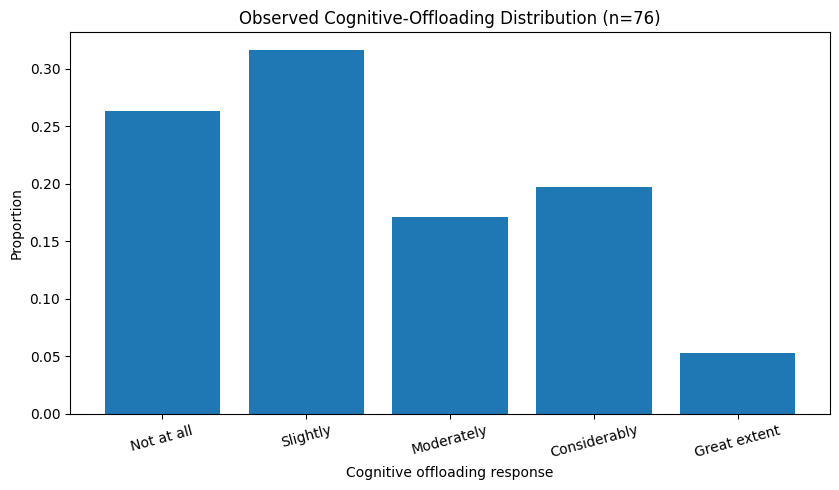

In [7]:
# Observed cognitive-offloading distribution

categories = [
    "Not at all", "Slightly", "Moderately",
    "Considerably", "Great extent"
]

obs_off = np.bincount(offloading, minlength=6)[1:] / len(offloading)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(categories, obs_off)
ax.set_ylabel("Proportion")
ax.set_xlabel("Cognitive offloading response")
ax.set_title("Observed Cognitive-Offloading Distribution (n=76)")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "observed_offloading_distribution.png", dpi=180)
plt.show()


# 6. Bayesian ordinal logistic model

## Primary model

**AI-use intensity → cognitive offloading**

Because offloading is an ordered 1–5 outcome, the model is an ordinal logistic regression:

\[
P(Y_i \le k)=\operatorname{logit}^{-1}(\theta_k - \beta X_i)
\]

where:

- \(Y_i\) = cognitive-offloading category
- \(X_i\) = standardized AI-use intensity
- \(	heta_k\) = ordered cutpoints
- \(eta\) = AI-use association

### Prior

\[
\beta \sim N(0,1)
\]

For the ordered cutpoints:

- first cutpoint ~ Normal(−1.5, 1)
- log-spacings ~ Normal(0, 0.5)

An initially broader cutpoint prior was rejected after prior-predictive inspection because it was excessively diffuse. The final prior was selected to allow a broad range of five-category response patterns without overwhelmingly concentrating probability in an extreme category.


In [8]:
# 7. Generic ordinal-logistic posterior functions

def unpack_ordinal(z, p):
    """z = [beta_1 ... beta_p, first_cutpoint, log_spacing_1 ... log_spacing_3]"""
    beta = z[:p]
    cutpoints = np.cumsum(np.r_[z[p], np.exp(z[p+1:])])
    return beta, cutpoints

def ordinal_log_posterior(z, X, y):
    p = X.shape[1]
    beta, cutpoints = unpack_ordinal(z, p)
    log_spacings = z[p+1:]

    # N(0,1) priors for beta
    lp = -0.5 * np.sum(beta**2) - p * 0.5 * np.log(2*np.pi)

    # N(-1.5, 1) prior for first cutpoint
    lp += -0.5 * (cutpoints[0] + 1.5)**2 - 0.5*np.log(2*np.pi)

    # N(0, 0.5) priors for log-spacings
    lp += np.sum(
        -0.5 * (log_spacings / 0.5)**2
        - np.log(0.5 * np.sqrt(2*np.pi))
    )

    eta = cutpoints[None, :] - (X @ beta)[:, None]
    cdf = expit(eta)

    probs = np.empty(len(y))
    probs[y == 1] = cdf[y == 1, 0]

    for k in range(1, 4):
        probs[y == k + 1] = (
            cdf[y == k + 1, k] -
            cdf[y == k + 1, k - 1]
        )

    probs[y == 5] = 1 - cdf[y == 5, 3]

    if np.any(probs <= 0):
        return -np.inf

    return lp + np.log(probs).sum()


def rhat(chains_2d):
    """Split-chain style basic Gelman-Rubin R-hat calculation."""
    m, n = chains_2d.shape
    B = n * np.var(chains_2d.mean(axis=1), ddof=1)
    W = np.mean(np.var(chains_2d, axis=1, ddof=1))
    return np.sqrt(((n-1)/n * W + B/n) / W)


def ess(chains_2d, max_lag=3000):
    """Simple autocorrelation-based effective sample size estimate."""
    total = 0.0

    for chain in chains_2d:
        n = len(chain)
        autocorrs = []

        for lag in range(1, min(n//2, max_lag)):
            r = np.corrcoef(chain[:-lag], chain[lag:])[0, 1]
            autocorrs.append(r)

            if lag > 1 and autocorrs[-1] + autocorrs[-2] < 0:
                break

        tau = 1 + 2 * sum(max(0, r) for r in autocorrs)
        total += n / tau

    return total


In [9]:
# 8. Random-walk Metropolis-Hastings sampler

def initial_cutpoints(y):
    counts = np.bincount(y, minlength=6)[1:]
    cumulative = np.cumsum(counts[:-1]) / len(y)
    return norm.ppf(np.clip(cumulative, 0.05, 0.95))

def run_mh_ordinal(
    X, y, seed,
    n_iter=40000,
    burn=15000,
    thin=5,
    proposal_scales=None
):
    p = X.shape[1]
    rr = np.random.default_rng(seed)

    if proposal_scales is None:
        proposal_scales = np.r_[
            np.repeat(0.16, p),
            [0.18],
            np.repeat(0.12, 3)
        ]

    th = initial_cutpoints(y)

    # Initial state
    current = np.r_[
        np.zeros(p),
        th[0],
        np.log(np.diff(th))
    ]

    current_lp = ordinal_log_posterior(current, X, y)

    saved = []
    accepted = 0

    for iteration in range(n_iter):
        proposal = current + rr.normal(0, proposal_scales)
        proposal_lp = ordinal_log_posterior(proposal, X, y)

        if np.log(rr.random()) < proposal_lp - current_lp:
            current = proposal
            current_lp = proposal_lp
            accepted += 1

        if iteration >= burn and (iteration - burn) % thin == 0:
            saved.append(current.copy())

    return np.asarray(saved), accepted / n_iter


In [10]:
# 9. Fit the primary model

X1 = ai_z[:, None]
y1 = offloading

# 4 chains; 40,000 iterations; 15,000 warm-up; thinning=5
chains1 = []

for chain_id in range(4):
    samples, acceptance = run_mh_ordinal(
        X1,
        y1,
        seed=SEED + 10 * chain_id,
        n_iter=40000,
        burn=15000,
        thin=5,
        proposal_scales=np.array([0.22, 0.18, 0.14, 0.14, 0.14])
    )
    chains1.append(samples)
    print(
        f"Chain {chain_id+1}: "
        f"saved draws={len(samples):,}, "
        f"acceptance={acceptance:.3f}"
    )

chains1 = np.asarray(chains1)

np.savez(
    OUTPUT_DIR / "model1_posterior.npz",
    chains=chains1,
    X=X1,
    y=y1,
    ai=ai
)

print("Posterior array shape:", chains1.shape)


Chain 1: saved draws=5,000, acceptance=0.392
Chain 2: saved draws=5,000, acceptance=0.383
Chain 3: saved draws=5,000, acceptance=0.386
Chain 4: saved draws=5,000, acceptance=0.393
Posterior array shape: (4, 5000, 5)


In [11]:
# 10. Primary posterior summary

beta_chains = chains1[:, :, 0]
beta = beta_chains.ravel()

model1_summary = {
    "posterior_mean": beta.mean(),
    "posterior_median": np.median(beta),
    "ci_2.5%": np.quantile(beta, 0.025),
    "ci_97.5%": np.quantile(beta, 0.975),
    "P(beta > 0)": np.mean(beta > 0),
    "median_OR": np.median(np.exp(beta)),
    "OR_2.5%": np.quantile(np.exp(beta), 0.025),
    "OR_97.5%": np.quantile(np.exp(beta), 0.975),
    "R_hat": rhat(beta_chains),
    "ESS": ess(beta_chains),
}

model1_summary


{'posterior_mean': np.float64(-0.2896031061137147),
 'posterior_median': np.float64(-0.28860119136895623),
 'ci_2.5%': np.float64(-0.698523307367339),
 'ci_97.5%': np.float64(0.10562148608442712),
 'P(beta > 0)': np.float64(0.07755),
 'median_OR': np.float64(0.7493109776646862),
 'OR_2.5%': np.float64(0.49731915162121426),
 'OR_97.5%': np.float64(1.1114011160951505),
 'R_hat': np.float64(1.000285047213057),
 'ESS': np.float64(7512.38962121419)}

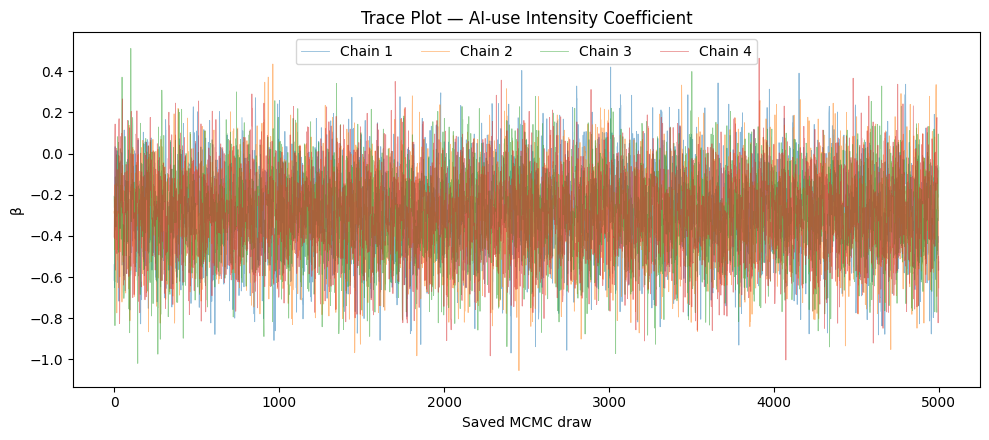

In [12]:
# 11. Trace plot

fig, ax = plt.subplots(figsize=(10, 4.5))

for j in range(4):
    ax.plot(
        chains1[j, :, 0],
        lw=0.6,
        alpha=0.5,
        label=f"Chain {j+1}"
    )

ax.set_xlabel("Saved MCMC draw")
ax.set_ylabel("β")
ax.set_title("Trace Plot — AI-use Intensity Coefficient")
ax.legend(ncol=4)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "model1_trace.png", dpi=180)
plt.show()


## 12. Prior predictive check

The prior predictive distribution asks:

> Before seeing the observed outcome, does the chosen prior generate plausible five-category response distributions?

This is a model-specification check, not a test of the hypothesis.


In [13]:
# Prior predictive simulation

prior_predictive = []

for _ in range(5000):
    beta_draw = rng.normal(0, 1)
    first_cut = rng.normal(-1.5, 1)
    log_spacings = rng.normal(0, 0.5, 3)

    cutpoints = np.cumsum(
        np.r_[first_cut, np.exp(log_spacings)]
    )

    cdf = expit(
        cutpoints[None, :] -
        beta_draw * ai_z[:, None]
    )

    probs = np.column_stack([
        cdf[:, 0],
        cdf[:, 1] - cdf[:, 0],
        cdf[:, 2] - cdf[:, 1],
        cdf[:, 3] - cdf[:, 2],
        1 - cdf[:, 3],
    ])

    u = rng.random(len(y1))
    replicated = (
        (u[:, None] > np.cumsum(probs, axis=1))
        .sum(axis=1) + 1
    )

    prior_predictive.append(
        np.bincount(replicated, minlength=6)[1:] / len(y1)
    )

prior_predictive = np.asarray(prior_predictive)

np.savez(
    OUTPUT_DIR / "model1_prior_predictive.npz",
    prior=prior_predictive
)

prior_mean = prior_predictive.mean(axis=0)
prior_ci = np.quantile(prior_predictive, [0.025, 0.975], axis=0)

prior_table = pd.DataFrame({
    "category": categories,
    "prior_predictive_mean": prior_mean,
    "prior_2.5%": prior_ci[0],
    "prior_97.5%": prior_ci[1],
    "observed": obs_off,
})

display(prior_table.round(3))


,category,prior_predictive_mean,prior_2.5%,prior_97.5%,observed
0,Not at all,0.245,0.026,0.605,0.263
1,Slightly,0.188,0.013,0.513,0.316
2,Moderately,0.193,0.039,0.474,0.171
3,Considerably,0.156,0.013,0.408,0.197
4,Great extent,0.219,0.000,0.684,0.053


### Prior-predictive decision

The final cutpoint prior is retained because the observed proportions fall within the broad prior-predictive ranges. An earlier much broader cutpoint prior was not retained because it produced an excessively diffuse predictive distribution.


## 13. Posterior predictive check

Now use posterior draws to generate replicated datasets and compare them with the actual observed distribution.

This checks whether the fitted ordinal model can reproduce the broad response pattern.


In [14]:
# Posterior predictive simulation

flat1 = chains1.reshape(-1, chains1.shape[-1])
pp_indices = rng.choice(len(flat1), size=1000, replace=False)

posterior_predictive = []

for idx in pp_indices:
    beta_draw, cutpoints = unpack_ordinal(flat1[idx], 1)

    cdf = expit(
        cutpoints[None, :] -
        (X1 @ beta_draw)[:, None]
    )

    probs = np.column_stack([
        cdf[:, 0],
        cdf[:, 1] - cdf[:, 0],
        cdf[:, 2] - cdf[:, 1],
        cdf[:, 3] - cdf[:, 2],
        1 - cdf[:, 3],
    ])

    u = rng.random(len(y1))
    replicated = (
        (u[:, None] > np.cumsum(probs, axis=1))
        .sum(axis=1) + 1
    )

    posterior_predictive.append(
        np.bincount(replicated, minlength=6)[1:] / len(y1)
    )

posterior_predictive = np.asarray(posterior_predictive)

np.savez(
    OUTPUT_DIR / "model1_ppc.npz",
    post=posterior_predictive,
    obs=obs_off
)

ppc_mean = posterior_predictive.mean(axis=0)
ppc_ci = np.quantile(posterior_predictive, [0.025, 0.975], axis=0)

ppc_table = pd.DataFrame({
    "category": categories,
    "observed": obs_off,
    "pp_mean": ppc_mean,
    "pp_2.5%": ppc_ci[0],
    "pp_97.5%": ppc_ci[1],
})

display(ppc_table.round(3))


,category,observed,pp_mean,pp_2.5%,pp_97.5%
0,Not at all,0.263,0.269,0.145,0.421
1,Slightly,0.316,0.303,0.184,0.447
2,Moderately,0.171,0.179,0.079,0.316
3,Considerably,0.197,0.182,0.079,0.316
4,Great extent,0.053,0.068,0.013,0.158


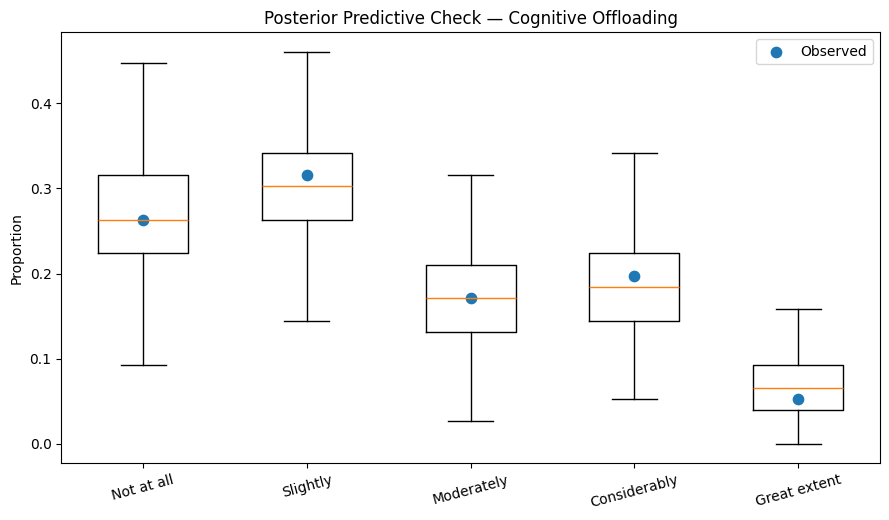

In [15]:
# PPC plot

fig, ax = plt.subplots(figsize=(9, 5.3))

ax.boxplot(
    [posterior_predictive[:, i] for i in range(5)],
    positions=np.arange(1, 6),
    widths=0.55,
    showfliers=False
)

ax.scatter(
    np.arange(1, 6),
    obs_off,
    s=55,
    label="Observed"
)

ax.set_xticks(np.arange(1, 6), categories, rotation=15)
ax.set_ylabel("Proportion")
ax.set_title("Posterior Predictive Check — Cognitive Offloading")
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "model1_ppc.png", dpi=180)
plt.show()


## 14. Primary model interpretation

The final primary posterior is approximately:

- β = **−0.290**
- 95% CrI = **[−0.699, 0.106]**
- P(β > 0 | data) = **0.078**
- OR per 1-SD increase in AI-use intensity = **0.749**
- 95% OR interval = **[0.497, 1.111]**

The posterior is centered on a negative association, but the credible interval includes zero. Therefore, this survey does **not** provide clear evidence for the hypothesized positive association between AI-use intensity and cognitive offloading.

Because the data are cross-sectional and observational, this cannot be interpreted causally.


# 15. Secondary Bayesian model — Verification behavior

Verification frequency is modeled as an ordinal outcome using:

1. standardized AI-use intensity
2. standardized AI-limitations awareness

This is **not** a direct test of the original trust hypothesis because the survey does not contain a defensible validated multi-item trust scale.


In [16]:
# Secondary model setup

X2 = np.column_stack([
    ai_z,
    (limitations_awareness - limitations_awareness.mean()) /
    limitations_awareness.std(ddof=1)
])

y2 = verification

chains2 = []

for chain_id in range(4):
    samples, acceptance = run_mh_ordinal(
        X2,
        y2,
        seed=SEED + 50 + chain_id,
        n_iter=40000,
        burn=15000,
        thin=5,
        proposal_scales=np.array([0.17, 0.17, 0.18, 0.13, 0.13, 0.13])
    )
    chains2.append(samples)
    print(
        f"Chain {chain_id+1}: "
        f"saved draws={len(samples):,}, "
        f"acceptance={acceptance:.3f}"
    )

chains2 = np.asarray(chains2)

np.savez(
    OUTPUT_DIR / "model2_verification_posterior.npz",
    chains=chains2,
    X=X2,
    y=y2
)


Chain 1: saved draws=5,000, acceptance=0.349
Chain 2: saved draws=5,000, acceptance=0.352
Chain 3: saved draws=5,000, acceptance=0.350
Chain 4: saved draws=5,000, acceptance=0.355


In [17]:
# Model 2 posterior summary

model2_rows = []

for k, name in enumerate([
    "AI-use intensity",
    "AI-limitations awareness"
]):
    vals = chains2[:, :, k]
    flat = vals.ravel()

    model2_rows.append({
        "predictor": name,
        "posterior_mean": flat.mean(),
        "median": np.median(flat),
        "ci_2.5%": np.quantile(flat, 0.025),
        "ci_97.5%": np.quantile(flat, 0.975),
        "P(beta>0)": np.mean(flat > 0),
        "R_hat": rhat(vals),
        "ESS": ess(vals)
    })

model2_summary = pd.DataFrame(model2_rows)
display(model2_summary.round(3))


,predictor,posterior_mean,median,ci_2.5%,ci_97.5%,P(beta>0),R_hat,ESS
0,AI-use intensity,0.218,0.216,-0.177,0.617,0.861,1.0,5110.573
1,AI-limitations awareness,0.370,0.371,-0.026,0.773,0.966,1.0,4628.797


In [18]:
# Model 2 posterior predictive check

flat2 = chains2.reshape(-1, chains2.shape[-1])
pp_indices2 = rng.choice(len(flat2), size=1000, replace=False)

pp2 = []

for idx in pp_indices2:
    beta_draw, cutpoints = unpack_ordinal(flat2[idx], 2)

    cdf = expit(
        cutpoints[None, :] -
        (X2 @ beta_draw)[:, None]
    )

    probs = np.column_stack([
        cdf[:, 0],
        cdf[:, 1] - cdf[:, 0],
        cdf[:, 2] - cdf[:, 1],
        cdf[:, 3] - cdf[:, 2],
        1 - cdf[:, 3],
    ])

    u = rng.random(len(y2))
    replicated = (
        (u[:, None] > np.cumsum(probs, axis=1))
        .sum(axis=1) + 1
    )

    pp2.append(
        np.bincount(replicated, minlength=6)[1:] / len(y2)
    )

pp2 = np.asarray(pp2)
obs_ver = np.bincount(y2, minlength=6)[1:] / len(y2)

model2_ppc = pd.DataFrame({
    "category": categories,
    "observed": obs_ver,
    "pp_mean": pp2.mean(axis=0),
    "pp_2.5%": np.quantile(pp2, 0.025, axis=0),
    "pp_97.5%": np.quantile(pp2, 0.975, axis=0),
})

display(model2_ppc.round(3))

np.savez(
    OUTPUT_DIR / "model2_verification_ppc.npz",
    post=pp2,
    obs=obs_ver
)


,category,observed,pp_mean,pp_2.5%,pp_97.5%
0,Not at all,0.118,0.138,0.053,0.250
1,Slightly,0.211,0.205,0.092,0.329
2,Moderately,0.355,0.337,0.211,0.474
3,Considerably,0.224,0.211,0.092,0.329
4,Great extent,0.092,0.109,0.026,0.211


# 16. Exploratory robustness models

These models are explicitly exploratory because:

- n=76 is modest,
- several variables are proxies/single items,
- the survey is observational,
- the original hypotheses were not all directly measurable.

### M3
Offloading ~ AI-use intensity + verification + AI-use × verification

### M4
Offloading ~ AI-use intensity + verification + limitations awareness + academic year

### M5
Dependency proxy ~ AI-use intensity + limitations awareness


In [19]:
# Generic multi-predictor fitting function for exploratory models

def fit_exploratory_model(
    X, y, name, proposal_scales, seed,
    n_iter=24000, burn=8000, thin=4
):
    chains = []

    for chain_id in range(4):
        samples, acceptance = run_mh_ordinal(
            X,
            y,
            seed=seed + chain_id,
            n_iter=n_iter,
            burn=burn,
            thin=thin,
            proposal_scales=proposal_scales
        )
        chains.append(samples)
        print(
            f"{name} | chain {chain_id+1} | "
            f"acceptance={acceptance:.3f}"
        )

    chains = np.asarray(chains)

    np.savez(
        OUTPUT_DIR / f"{name}.npz",
        chains=chains,
        X=X,
        y=y
    )

    rows = []
    for k in range(X.shape[1]):
        vals = chains[:, :, k]
        flat = vals.ravel()

        rows.append({
            "predictor_index": k,
            "posterior_mean": flat.mean(),
            "ci_2.5%": np.quantile(flat, 0.025),
            "ci_97.5%": np.quantile(flat, 0.975),
            "P(beta>0)": np.mean(flat > 0),
            "R_hat": rhat(vals),
            "ESS": ess(vals)
        })

    return chains, pd.DataFrame(rows)


In [20]:
# M3: interaction model

ver_z = (
    verification - verification.mean()
) / verification.std(ddof=1)

X3 = np.column_stack([
    ai_z,
    ver_z,
    ai_z * ver_z
])

chains3, summary3 = fit_exploratory_model(
    X3,
    offloading,
    "model3_offloading_interaction",
    np.array([0.16, 0.16, 0.12, 0.18, 0.12, 0.12, 0.12]),
    seed=20260926
)

summary3.index = [
    "AI-use intensity",
    "Verification",
    "AI-use × Verification"
]

display(summary3.round(3))


model3_offloading_interaction | chain 1 | acceptance=0.378
model3_offloading_interaction | chain 2 | acceptance=0.381
model3_offloading_interaction | chain 3 | acceptance=0.382
model3_offloading_interaction | chain 4 | acceptance=0.380


,predictor_index,posterior_mean,ci_2.5%,ci_97.5%,P(beta>0),R_hat,ESS
AI-use intensity,0,-0.307,-0.769,0.150,0.092,1.000,1624.405
Verification,1,-0.227,-0.651,0.182,0.142,1.001,2940.205
AI-use × Verification,2,-0.071,-0.521,0.381,0.381,1.000,1163.508


In [21]:
# M4: adjusted offloading model

lim_z = (
    limitations_awareness - limitations_awareness.mean()
) / limitations_awareness.std(ddof=1)

X4 = np.column_stack([
    ai_z,
    ver_z,
    lim_z,
    academic_year_z
])

chains4, summary4 = fit_exploratory_model(
    X4,
    offloading,
    "model4_offloading_adjusted",
    np.array([0.14, 0.14, 0.14, 0.14, 0.10, 0.10, 0.10, 0.10]),
    seed=20261026
)

summary4.index = [
    "AI-use intensity",
    "Verification",
    "Limitations awareness",
    "Academic year"
]

display(summary4.round(3))


model4_offloading_adjusted | chain 1 | acceptance=0.420
model4_offloading_adjusted | chain 2 | acceptance=0.416
model4_offloading_adjusted | chain 3 | acceptance=0.423
model4_offloading_adjusted | chain 4 | acceptance=0.418


,predictor_index,posterior_mean,ci_2.5%,ci_97.5%,P(beta>0),R_hat,ESS
AI-use intensity,0,-0.264,-0.664,0.129,0.098,1.000,2419.022
Verification,1,-0.261,-0.696,0.147,0.112,1.001,2105.589
Limitations awareness,2,0.203,-0.244,0.669,0.810,1.001,1982.466
Academic year,3,0.162,-0.256,0.583,0.772,1.001,2248.013


In [22]:
# M5: dependency proxy

X5 = np.column_stack([
    ai_z,
    lim_z
])

chains5, summary5 = fit_exploratory_model(
    X5,
    dependency_proxy,
    "model5_dependency_proxy",
    np.array([0.16, 0.16, 0.17, 0.12, 0.12, 0.12]),
    seed=20261126
)

summary5.index = [
    "AI-use intensity",
    "Limitations awareness"
]

display(summary5.round(3))


model5_dependency_proxy | chain 1 | acceptance=0.435
model5_dependency_proxy | chain 2 | acceptance=0.432
model5_dependency_proxy | chain 3 | acceptance=0.433
model5_dependency_proxy | chain 4 | acceptance=0.435


,predictor_index,posterior_mean,ci_2.5%,ci_97.5%,P(beta>0),R_hat,ESS
AI-use intensity,0,0.461,0.045,0.885,0.986,1.001,3075.230
Limitations awareness,1,-0.561,-0.994,-0.142,0.003,1.001,2704.863


## 17. Exploratory model results

The key robustness results are:

| Model | Predictor | Posterior mean | 95% CrI | P(β>0) |
|---|---|---:|---:|---:|
| M3 | AI-use intensity | −0.301 | [−0.751, 0.154] | 0.098 |
| M3 | Verification | −0.223 | [−0.650, 0.188] | 0.147 |
| M3 | AI-use × verification | −0.064 | [−0.497, 0.387] | 0.382 |
| M4 | AI-use intensity | −0.264 | [−0.664, 0.129] | 0.098 |
| M4 | Verification | −0.261 | [−0.696, 0.147] | 0.112 |
| M4 | Limitations awareness | 0.203 | [−0.244, 0.669] | 0.810 |
| M4 | Academic year | 0.162 | [−0.256, 0.583] | 0.772 |
| M5 | AI-use intensity | 0.461 | [0.045, 0.885] | 0.986 |
| M5 | Limitations awareness | −0.561 | [−0.994, −0.142] | 0.003 |

The primary AI-use coefficient remains negative with credible intervals crossing zero after exploratory adjustment.


# 18. Descriptive Spearman association matrix

Spearman correlations are included only as descriptive summaries. They are not substitutes for the Bayesian ordinal models.


In [23]:
corr_df = pd.DataFrame({
    "AI_use_intensity": ai,
    "offloading": offloading,
    "verification": verification,
    "reasoning_request": reasoning_request,
    "comfort_without_ai": comfort_without_ai,
    "dependency_proxy": dependency_proxy,
    "limitations_awareness": limitations_awareness,
    "academic_year": academic_year,
})

spearman = corr_df.corr(method="spearman").round(3)
display(spearman)

corr_df.to_csv(OUTPUT_DIR / "analysis_variables.csv", index=False)


,AI_use_intensity,offloading,verification,reasoning_request,comfort_without_ai,dependency_proxy,limitations_awareness,academic_year
AI_use_intensity,1.000,-0.200,0.114,0.308,-0.368,0.310,-0.084,-0.062
offloading,-0.200,1.000,-0.162,-0.139,0.082,-0.061,0.073,0.053
verification,0.114,-0.162,1.000,0.153,0.096,-0.035,0.224,-0.125
reasoning_request,0.308,-0.139,0.153,1.000,-0.192,0.076,-0.111,-0.107
comfort_without_ai,-0.368,0.082,0.096,-0.192,1.000,-0.389,0.334,0.253
dependency_proxy,0.310,-0.061,-0.035,0.076,-0.389,1.000,-0.425,0.014
limitations_awareness,-0.084,0.073,0.224,-0.111,0.334,-0.425,1.000,-0.012
academic_year,-0.062,0.053,-0.125,-0.107,0.253,0.014,-0.012,1.000


# 19. Hypothesis-by-hypothesis conclusion

### H1 — AI reliance and cognitive offloading
The survey contains usable proxies for both constructs. The primary Bayesian model does **not** show a clear positive association.

### H2 — Trust and verification
The survey does not provide a validated multi-item trust scale. A direct trust → verification hypothesis is therefore not tested as originally specified.

### H3 — Verification and clinical reasoning performance
There is no direct clinical-reasoning performance score in the survey. Reserve for Phase 3.

### H4 — AI literacy moderating AI reliance → learning performance
There is no validated AI-literacy scale and no direct learning-performance outcome. Reserve for Phase 3.

### H5 — AI reliance without verification → confidence calibration
Confidence and actual performance are not paired at the task level. Reserve for Phase 3.

### H6 — MedTrust AI vs conventional AI
This survey has no randomized interface condition. Reserve for Phase 3.

## Bottom line

The Phase 1 survey supports analysis of **AI use, verification, self-reported independent-thinking reduction, and dependency-related patterns**, but it cannot establish the causal or experimental claims reserved for the later controlled evaluation.


# 20. Limitations

1. Cross-sectional self-report data cannot establish causal direction.
2. The sample size is modest (n=76).
3. The academic-year distribution is concentrated in later years.
4. Several constructs are single-item measures or proxies rather than validated multi-item scales.
5. Trust, clinical reasoning performance, and confidence calibration are not directly measured at the level required by the original hypotheses.
6. Self-reported AI use and verification may differ from observed behavior.
7. The MCMC implementation uses a reproducible random-walk Metropolis-Hastings sampler because the available PyMC/ArviZ environment had an interface incompatibility.
8. PSIS-LOO is not used as a central result because the principal question does not require predictive model selection and the intended ArviZ workflow was unavailable.


# 21. Recommended Phase 3 analysis

The controlled experiment should collect:

- task-level clinical reasoning correctness,
- observed verification actions,
- pre/post learning scores,
- delayed retention,
- confidence paired with correctness,
- AI reliance,
- interface condition (conventional AI vs MedTrust AI),
- repeated-task identifiers if applicable.

These data would allow Bayesian hierarchical models for treatment effects, learning change, verification, clinical reasoning, and confidence calibration.

The Phase 1 survey and Phase 3 experiment should remain analytically separate.


# 22. Reproducibility

**Seed:** `20260926`

Primary model:
- 4 chains
- 40,000 iterations per chain
- 15,000 warm-up
- thinning = 5
- 5,000 retained draws per chain
- 20,000 total retained posterior draws

Posterior predictive check:
- 1,000 posterior draws

The raw CSV is the source dataset. All model outputs are saved under `trustcal_bayes_outputs/`.

## Expected primary result

- β ≈ −0.290
- 95% CrI ≈ [−0.699, 0.106]
- P(β>0) ≈ 0.078
- OR ≈ 0.749
- 95% OR interval ≈ [0.497, 1.111]
- R-hat ≈ 1.000
- ESS ≈ 7,512
